# Deep Crossentropy method

In this section we'll extend your CEM implementation with neural networks! You will train a multi-layer neural network to solve simple continuous state space games. __Please make sure you're done with tabular crossentropy method from the previous notebook.__

![img](https://watanimg.elwatannews.com/old_news_images/large/249765_Large_20140709045740_11.jpg)



In [ ]:
import sys, os
if 'google.colab' in sys.modules and not os.path.exists('.setup_complete'):
    !wget -q https://raw.githubusercontent.com/yandexdataschool/Practical_RL/master/setup_colab.sh -O- | bash
    !touch .setup_complete

# This code creates a virtual display to draw game images on.
# It will have no effect if your machine has a monitor.
if type(os.environ.get("DISPLAY")) is not str or len(os.environ.get("DISPLAY")) == 0:
    !bash ../xvfb start
    os.environ['DISPLAY'] = ':1'

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Starting virtual X frame buffer: Xvfb.


In [ ]:
# Install gymnasium if you didn't
!pip install "gymnasium[toy_text,classic_control]"

/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(


state vector dim = 4
n_actions = 2


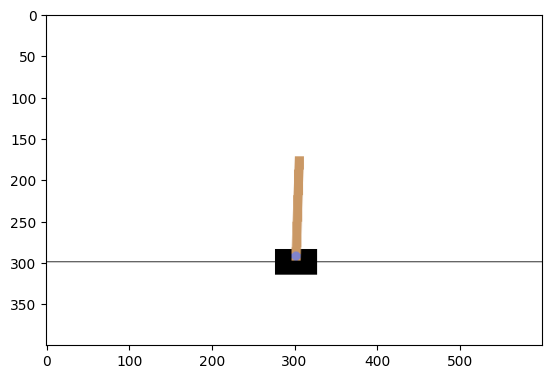

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

# if you see "<classname> has no attribute .env", remove .env or update gym
env = gym.make("CartPole-v0", render_mode="rgb_array").env

env.reset()
n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

plt.imshow(env.render())
print("state vector dim =", state_dim)
print("n_actions =", n_actions)

env.close()

# Neural Network Policy

For this assignment we'll utilize the simplified neural network implementation from __[Scikit-learn](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html)__. Here's what you'll need:

* `agent.partial_fit(states, actions)` - make a single training pass over the data. Maximize the probability of :actions: from :states:
* `agent.predict_proba(states)` - predict probabilities of all actions, a matrix of shape __[len(states), n_actions]__


In [ ]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(20, 20),
    activation="tanh",
)

# initialize agent to the dimension of state space and number of actions
agent.partial_fit([env.reset()[0]] * n_actions, range(n_actions), classes=range(n_actions))

MLPClassifier(activation='tanh', hidden_layer_sizes=(20, 20))

In [ ]:
def generate_session(env, agent, t_max=1000):
    """
    Play a single game using agent neural network.
    Terminate when game finishes or after :t_max: steps
    """
    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):

        # use agent to predict a vector of action probabilities for state :s:
        probs = agent.predict_proba([s])[0]

        probs = probs / np.sum(probs)

        assert probs.shape == (env.action_space.n,), "make sure probabilities are a vector (hint: np.reshape)"

        # use the probabilities you predicted to pick an action
        # sample proportionally to the probabilities, don't just take the most likely action
        a = np.random.choice(env.action_space.n, p=probs)
        # ^-- hint: try np.random.choice

        new_s, r, terminated, truncated, _ = env.step(a)

        # record sessions like you did before
        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s
        if terminated or truncated:
            break
    return states, actions, total_reward


In [ ]:
dummy_states, dummy_actions, dummy_reward = generate_session(env, agent, t_max=5)
print("states:", np.stack(dummy_states))
print("actions:", dummy_actions)
print("reward:", dummy_reward)


states: [[ 1.8478336e-02 -3.6984153e-02  7.3917944e-04 -3.9079733e-02]
 [ 1.7738651e-02 -2.3211670e-01 -4.2415228e-05  2.5383633e-01]
 [ 1.3096319e-02 -3.6994137e-02  5.0343112e-03 -3.8859986e-02]
 [ 1.2356436e-02 -2.3218791e-01  4.2571113e-03  2.5540707e-01]
 [ 7.7126771e-03 -3.7127007e-02  9.3652522e-03 -3.5930071e-02]]
actions: [0, 1, 0, 1, 0]
reward: 5.0


### CEM steps
Deep CEM uses exactly the same strategy as the regular CEM, so you can copy your function code from previous notebook.

The only difference is that now each observation is not a number but a `float32` vector.

In [ ]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=50):
    """
    Select states and actions from games that have rewards >= percentile.
    """

    reward_threshold = np.percentile(rewards_batch, percentile)

    elite_states = []
    elite_actions = []

    for states, actions, reward in zip(states_batch, actions_batch, rewards_batch):
        if reward >= reward_threshold:
            elite_states.extend(states)
            elite_actions.extend(actions)

    return elite_states, elite_actions


# Training loop
Generate sessions, select N best and fit to those.

In [ ]:
from IPython.display import clear_output


def show_progress(rewards_batch, log, percentile, reward_range=[-990, +10]):
    """
    A convenience function that displays training progress.
    No cool math here, just charts.
    """

    mean_reward = np.mean(rewards_batch)
    threshold = np.percentile(rewards_batch, percentile)
    log.append([mean_reward, threshold])

    clear_output(True)
    print("mean reward = %.3f, threshold=%.3f" % (mean_reward, threshold))
    plt.figure(figsize=[8, 4])
    plt.subplot(1, 2, 1)
    plt.plot(list(zip(*log))[0], label="Mean rewards")
    plt.plot(list(zip(*log))[1], label="Reward thresholds")
    plt.legend()
    plt.grid()

    plt.subplot(1, 2, 2)
    plt.hist(rewards_batch, range=reward_range)
    plt.vlines(
        [np.percentile(rewards_batch, percentile)],
        [0],
        [100],
        label="percentile",
        color="red",
    )
    plt.legend()
    plt.grid()

    plt.show()


mean reward = 197.190, threshold=219.000


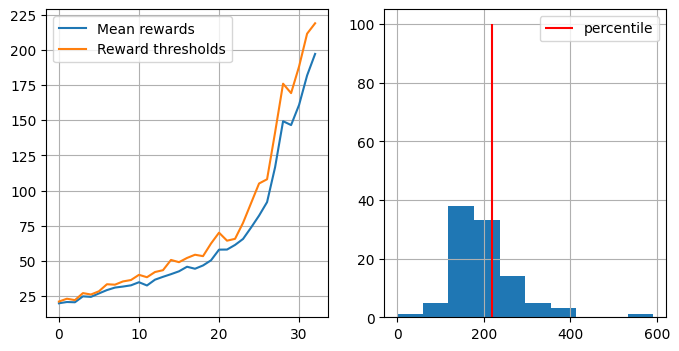

You Win! You may stop training now.


In [ ]:
n_sessions = 100
percentile = 70
log = []

for i in range(100):
    sessions = [
        generate_session(env, agent)
        for _ in range(n_sessions)
    ]

    states_batch, actions_batch, rewards_batch = zip(*sessions)
    rewards_batch = np.array(rewards_batch)

    elite_states, elite_actions = select_elites(
        states_batch,
        actions_batch,
        rewards_batch,
        percentile
    )

    elite_states = np.array(elite_states)
    elite_actions = np.array(elite_actions)

    agent.partial_fit(
        elite_states,
        elite_actions,
        classes=range(n_actions)
    )

    show_progress(
        rewards_batch,
        log,
        percentile,
        reward_range=[0, np.max(rewards_batch)]
    )

    if np.mean(rewards_batch) > 190:
        print("You Win! You may stop training now.")
        break

# Results

In [ ]:
# Record sessions

from gymnasium.wrappers import RecordVideo

with RecordVideo(
    env=gym.make("CartPole-v0", render_mode="rgb_array"),
    video_folder="./videos",
    episode_trigger=lambda episode_number: True,
) as env_monitor:
    sessions = [generate_session(env_monitor, agent) for _ in range(100)]


/usr/local/lib/python3.12/dist-packages/gymnasium/envs/registration.py:512: DeprecationWarning: WARN: The environment CartPole-v0 is out of date. You should consider upgrading to version `v1`.
  logger.deprecation(
/usr/local/lib/python3.12/dist-packages/moviepy/config_defaults.py:47: SyntaxWarning: invalid escape sequence '\P'
  IMAGEMAGICK_BINARY = r"C:\Program Files\ImageMagick-6.8.8-Q16\magick.exe"


In [ ]:
# Show video. This may not work in some setups. If it doesn't
# work for you, you can download the videos and view them locally.

from pathlib import Path
from base64 import b64encode
from IPython.display import HTML

video_paths = sorted([s for s in Path("videos").iterdir() if s.suffix == ".mp4"])
video_path = video_paths[-1]  # You can also try other indices

if "google.colab" in sys.modules:
    # https://stackoverflow.com/a/57378660/1214547
    with video_path.open("rb") as fp:
        mp4 = fp.read()
    data_url = "data:video/mp4;base64," + b64encode(mp4).decode()
else:
    data_url = str(video_path)

HTML(
    """
<video width="640" height="480" controls>
  <source src="{}" type="video/mp4">
</video>
""".format(
        data_url
    )
)


# Homework part I

### Tabular crossentropy method

You may have noticed that the taxi problem quickly converges from -100 to a near-optimal score and then descends back into -50/-100. This is in part because the environment has some innate randomness. Namely, the starting points of passenger/driver change from episode to episode.

### Tasks
- __1.1__ (2 pts) Find out how the algorithm performance changes if you use a different `percentile` and/or `n_sessions`. Provide here some figures so we can see how the hyperparameters influence the performance.
- __1.2__ (1 pts) Tune the algorithm to end up with positive average score.

It's okay to modify the existing code.


Смотреть файл crossentropy_method

# Homework part II

### Deep crossentropy method

By this moment, you should have got enough score on [CartPole-v0](https://gymnasium.farama.org/environments/classic_control/cart_pole/) to consider it solved (see the link). It's time to try something harder.

* if you have any trouble with CartPole-v0 and feel stuck, feel free to ask us or your peers for help.

### Tasks

* __2.1__ (3 pts) Pick one of environments: `MountainCar-v0` or `LunarLander-v2`.
  * For MountainCar, get average reward of __at least -150__
  * For LunarLander, get average reward of __at least +50__

See the tips section below, it's kinda important.
__Note:__ If your agent is below the target score, you'll still get some of the points depending on the result, so don't be afraid to submit it.
  
  
* __2.2__ (up to 6 pts) Devise a way to speed up training against the default version
  * Obvious improvement: use [`joblib`](https://joblib.readthedocs.io/en/latest/). However, note that you will probably need to spawn a new environment in each of the workers instead of passing it via pickling. (2 pts)
  * Try re-using samples from 3-5 last iterations when computing threshold and training. (2 pts)
  * Obtain __-100__ at `MountainCar-v0` or __+200__ at `LunarLander-v2` (2 pts). Feel free to experiment with hyperparameters, architectures, schedules etc.
  
__Please list what you did in Anytask submission form__. This reduces probability that somebody misses something.
  
  
### Tips
* Gymnasium pages: [MountainCar](https://gymnasium.farama.org/environments/classic_control/mountain_car/), [LunarLander](https://gymnasium.farama.org/environments/box2d/lunar_lander/)
* Sessions for MountainCar may last for 10k+ ticks. Make sure ```t_max``` param is at least 10k.
 * Also it may be a good idea to cut rewards via ">" and not ">=". If 90% of your sessions get reward of -10k and 10% are better, than if you use percentile 20% as threshold, R >= threshold __fails to cut off bad sessions__ while R > threshold works alright.
* _issue with gym_: Some versions of gym limit game time by 200 ticks. This will prevent cem training in most cases. Make sure your agent is able to play for the specified __t_max__, and if it isn't, try `env = gym.make("MountainCar-v0").env` or otherwise get rid of TimeLimit wrapper.
* If you use old _swig_ lib for LunarLander-v2, you may get an error. See this [issue](https://github.com/openai/gym/issues/100) for solution.
* If it doesn't train, it's a good idea to plot reward distribution and record sessions: they may give you some clue. If they don't, call course staff :)
* 20-neuron network is probably not enough, feel free to experiment.

You may find the following snippet useful:

state vector dim = 2
n_actions = 3
first state = [-0.4452088  0.       ]


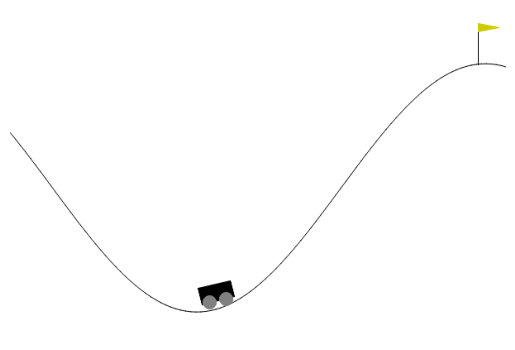

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("MountainCar-v0", render_mode="rgb_array").env

s, _ = env.reset(seed=42)

n_actions = env.action_space.n
state_dim = env.observation_space.shape[0]

print("state vector dim =", state_dim)
print("n_actions =", n_actions)
print("first state =", s)

plt.imshow(env.render())
plt.axis("off");

In [ ]:
obs_low = env.observation_space.low
obs_high = env.observation_space.high

def preprocess_states(states):

    states = np.asarray(states)
    return 2 * (states - obs_low) / (obs_high - obs_low) - 1

In [ ]:
from sklearn.neural_network import MLPClassifier

agent = MLPClassifier(
    hidden_layer_sizes=(64, 64),
    activation="tanh",
    learning_rate_init=1e-3,
    alpha=1e-4,
    max_iter=1,
    warm_start=True,
    random_state=42
)

s0, _ = env.reset(seed=42)

agent.partial_fit(
    preprocess_states(np.repeat(s0[None, :], n_actions, axis=0)),
    np.arange(n_actions),
    classes=np.arange(n_actions)
)

MLPClassifier(activation='tanh', hidden_layer_sizes=(64, 64), max_iter=1,
              random_state=42, warm_start=True)

In [ ]:
def generate_session(env, agent, t_max=10_000, epsilon=0.05, greedy=False):

    states, actions = [], []
    total_reward = 0

    s, _ = env.reset()

    for t in range(t_max):
        probs = agent.predict_proba(preprocess_states([s]))[0]
        probs = probs / np.sum(probs)

        if greedy:
            a = int(np.argmax(probs))
        else:
            probs = (1 - epsilon) * probs + epsilon / env.action_space.n
            probs = probs / np.sum(probs)
            a = np.random.choice(env.action_space.n, p=probs)

        new_s, r, terminated, truncated, _ = env.step(a)

        states.append(s)
        actions.append(a)
        total_reward += r

        s = new_s

        if terminated or truncated:
            break

    return states, actions, total_reward

In [ ]:
def select_elites(states_batch, actions_batch, rewards_batch, percentile=70):

    rewards_batch = np.asarray(rewards_batch)
    reward_threshold = np.percentile(rewards_batch, percentile)

    elite_states = []
    elite_actions = []

    for states, actions, reward in zip(states_batch, actions_batch, rewards_batch):
        if reward > reward_threshold:
            elite_states.extend(states)
            elite_actions.extend(actions)

    if len(elite_states) == 0:
        best_reward = np.max(rewards_batch)
        for states, actions, reward in zip(states_batch, actions_batch, rewards_batch):
            if reward == best_reward:
                elite_states.extend(states)
                elite_actions.extend(actions)

    return np.asarray(elite_states), np.asarray(elite_actions)

In [ ]:
def evaluate_policy(env, agent, n_games=30, t_max=10_000):
    rewards = []

    for _ in range(n_games):
        _, _, reward = generate_session(
            env,
            agent,
            t_max=t_max,
            epsilon=0.0,
            greedy=True
        )
        rewards.append(reward)

    return np.mean(rewards), np.std(rewards)

In [ ]:
from collections import deque
from IPython.display import clear_output

def train_cem_mountain_car(
    env,
    agent,
    n_sessions=80,
    percentile=70,
    n_iterations=100,
    replay_size=4,
    t_max=10_000,
    epsilon=0.05,
    max_train_steps=50_000,
    target_score=-150
):
    log = []
    replay_buffer = deque(maxlen=replay_size)

    for iteration in range(n_iterations):
        sessions = [
            generate_session(env, agent, t_max=t_max, epsilon=epsilon, greedy=False)
            for _ in range(n_sessions)
        ]

        replay_buffer.append(sessions)

        train_sessions = [
            session
            for batch in replay_buffer
            for session in batch
        ]

        states_batch, actions_batch, rewards_batch = zip(*train_sessions)
        rewards_batch = np.asarray(rewards_batch)

        elite_states, elite_actions = select_elites(
            states_batch,
            actions_batch,
            rewards_batch,
            percentile=percentile
        )


        if len(elite_states) > max_train_steps:
            idx = np.random.choice(len(elite_states), size=max_train_steps, replace=False)
            elite_states = elite_states[idx]
            elite_actions = elite_actions[idx]

        agent.partial_fit(
            preprocess_states(elite_states),
            elite_actions,
            classes=np.arange(n_actions)
        )

        current_rewards = np.asarray([session[2] for session in sessions])

        eval_mean, eval_std = evaluate_policy(
            env,
            agent,
            n_games=20,
            t_max=t_max
        )

        log.append({
            "iteration": iteration,
            "mean_reward": np.mean(current_rewards),
            "threshold": np.percentile(rewards_batch, percentile),
            "eval_mean": eval_mean,
            "eval_std": eval_std
        })

        clear_output(True)

        print(f"iteration: {iteration}")
        print(f"mean train reward: {np.mean(current_rewards):.2f}")
        print(f"elite threshold: {np.percentile(rewards_batch, percentile):.2f}")
        print(f"greedy eval reward: {eval_mean:.2f} ± {eval_std:.2f}")

        plt.figure(figsize=(10, 5))

        plt.plot([x["mean_reward"] for x in log], label="mean train reward")
        plt.plot([x["threshold"] for x in log], label="elite threshold")
        plt.plot([x["eval_mean"] for x in log], label="greedy eval reward")

        plt.axhline(target_score, linestyle="--", label="target score = -150")

        plt.xlabel("iteration")
        plt.ylabel("reward")
        plt.title("MountainCar-v0: Deep CEM training")
        plt.legend()
        plt.grid()
        plt.show()

        if eval_mean >= target_score:
            print("Target reached!")
            break

    return agent, log

iteration: 27
mean train reward: -929.64
elite threshold: -1113.70
greedy eval reward: -149.85 ± 36.07


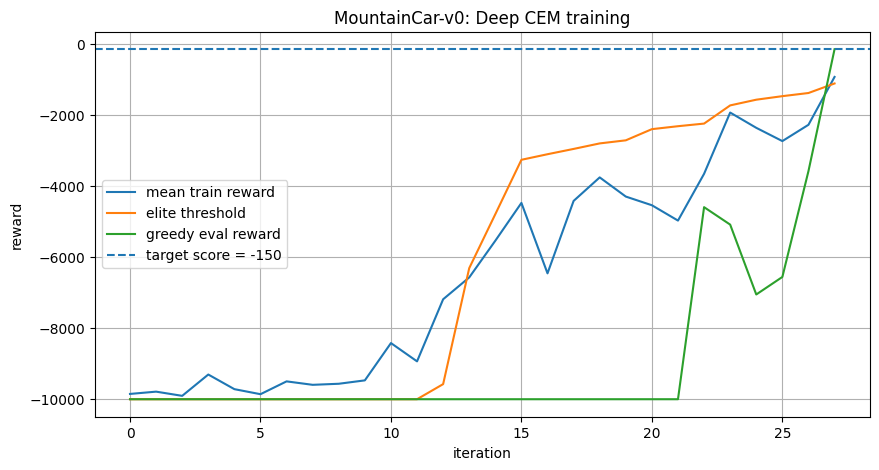

Target reached!


In [ ]:
agent, log = train_cem_mountain_car(
    env,
    agent,
    n_sessions=80,
    percentile=70,
    n_iterations=100,
    replay_size=4,
    t_max=10_000,
    epsilon=0.05,
    target_score=-150
)

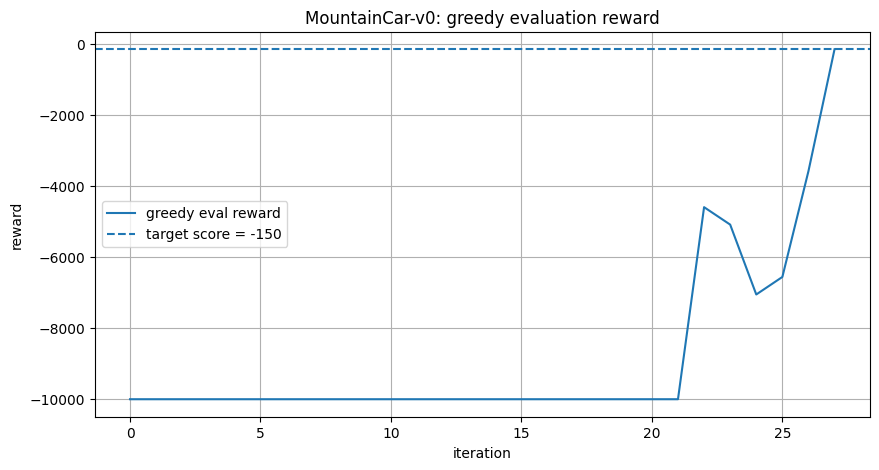

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot([x["eval_mean"] for x in log], label="greedy eval reward")
plt.axhline(-150, linestyle="--", label="target score = -150")

plt.xlabel("iteration")
plt.ylabel("reward")
plt.title("MountainCar-v0: greedy evaluation reward")
plt.legend()
plt.grid()
plt.show()

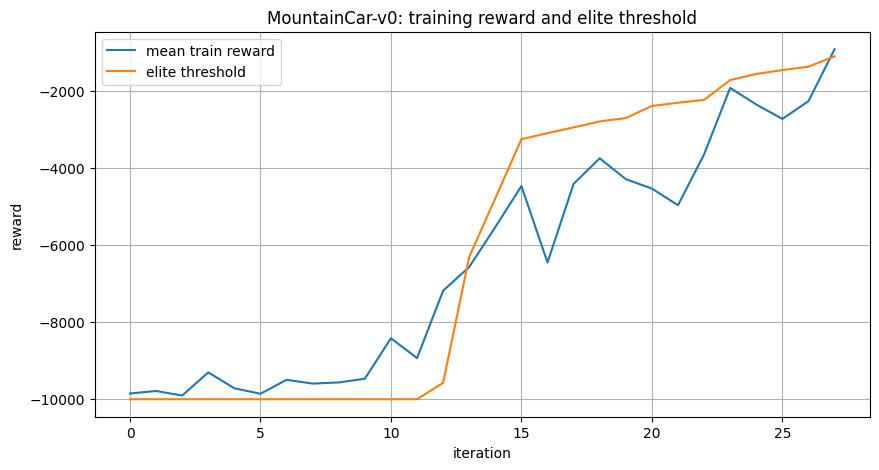

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot([x["mean_reward"] for x in log], label="mean train reward")
plt.plot([x["threshold"] for x in log], label="elite threshold")

plt.xlabel("iteration")
plt.ylabel("reward")
plt.title("MountainCar-v0: training reward and elite threshold")
plt.legend()
plt.grid()
plt.show()

In [ ]:
from sklearn.neural_network import MLPClassifier
import numpy as np

def create_agent_bonus(random_state=42):
    agent = MLPClassifier(
        hidden_layer_sizes=(128, 128),
        activation="tanh",
        solver="adam",
        learning_rate_init=5e-4,
        alpha=1e-5,
        max_iter=1,
        warm_start=True,
        random_state=random_state
    )

    s0, _ = env.reset(seed=random_state)

    agent.partial_fit(
        preprocess_states(np.repeat(s0[None, :], n_actions, axis=0)),
        np.arange(n_actions),
        classes=np.arange(n_actions)
    )

    return agent

In [ ]:
def select_elites_by_score(
    states_batch,
    actions_batch,
    scores_batch,
    percentile=60
):
    scores_batch = np.asarray(scores_batch)
    score_threshold = np.percentile(scores_batch, percentile)

    elite_states = []
    elite_actions = []

    for states, actions, score in zip(states_batch, actions_batch, scores_batch):
        if score > score_threshold:
            elite_states.extend(states)
            elite_actions.extend(actions)

    if len(elite_states) == 0:
        best_score = np.max(scores_batch)

        for states, actions, score in zip(states_batch, actions_batch, scores_batch):
            if score == best_score:
                elite_states.extend(states)
                elite_actions.extend(actions)

    return np.asarray(elite_states), np.asarray(elite_actions), score_threshold

In [ ]:
from joblib import Parallel, delayed
from collections import deque
from IPython.display import clear_output
import matplotlib.pyplot as plt
import copy
import time

def evaluate_policy_bonus(agent, n_games=50, t_max=10_000, n_jobs=2):
    sessions = Parallel(n_jobs=n_jobs)(
        delayed(generate_session_worker)(
            agent,
            seed=10_000 + i,
            t_max=t_max,
            epsilon=0.0,
            greedy=True
        )
        for i in range(n_games)
    )

    rewards = [session[2] for session in sessions]

    return np.mean(rewards), np.std(rewards)


def train_cem_mountain_car_full(
    agent,
    n_sessions=160,
    percentile=60,
    n_iterations=200,
    replay_size=5,
    t_max=10_000,
    epsilon_start=0.20,
    epsilon_min=0.02,
    epsilon_decay=0.97,
    train_epochs=3,
    max_train_steps=80_000,
    target_score=-100,
    n_jobs=2
):
    log = []
    replay_buffer = deque(maxlen=replay_size)

    best_agent = copy.deepcopy(agent)
    best_eval = -float("inf")

    start_time = time.time()

    for iteration in range(n_iterations):
        epsilon = max(epsilon_min, epsilon_start * (epsilon_decay ** iteration))


        sessions = Parallel(n_jobs=n_jobs)(
            delayed(generate_session_worker)(
                agent,
                seed=iteration * n_sessions + i,
                t_max=t_max,
                epsilon=epsilon,
                greedy=False
            )
            for i in range(n_sessions)
        )

        replay_buffer.append(sessions)


        train_sessions = [
            session
            for batch in replay_buffer
            for session in batch
        ]

        states_batch, actions_batch, true_rewards_batch, scores_batch = zip(*train_sessions)

        elite_states, elite_actions, score_threshold = select_elites_by_score(
            states_batch,
            actions_batch,
            scores_batch,
            percentile=percentile
        )


        if len(elite_states) > max_train_steps:
            idx = np.random.choice(
                len(elite_states),
                size=max_train_steps,
                replace=False
            )
            elite_states = elite_states[idx]
            elite_actions = elite_actions[idx]


        for _ in range(train_epochs):
            idx = np.random.permutation(len(elite_states))

            agent.partial_fit(
                preprocess_states(elite_states[idx]),
                elite_actions[idx],
                classes=np.arange(n_actions)
            )

        eval_mean, eval_std = evaluate_policy_bonus(
            agent,
            n_games=30,
            t_max=t_max,
            n_jobs=n_jobs
        )

        if eval_mean > best_eval:
            best_eval = eval_mean
            best_agent = copy.deepcopy(agent)

        current_true_rewards = np.asarray([session[2] for session in sessions])
        current_scores = np.asarray([session[3] for session in sessions])

        log.append({
            "iteration": iteration,
            "epsilon": epsilon,
            "mean_true_reward": np.mean(current_true_rewards),
            "mean_cem_score": np.mean(current_scores),
            "score_threshold": score_threshold,
            "eval_mean": eval_mean,
            "eval_std": eval_std,
            "best_eval": best_eval
        })

        clear_output(True)

        print(f"iteration: {iteration}")
        print(f"epsilon: {epsilon:.3f}")
        print(f"mean true train reward: {np.mean(current_true_rewards):.2f}")
        print(f"CEM score threshold: {score_threshold:.2f}")
        print(f"greedy eval reward: {eval_mean:.2f} ± {eval_std:.2f}")
        print(f"best greedy eval reward: {best_eval:.2f}")
        print(f"elapsed time: {time.time() - start_time:.1f} sec")

        plt.figure(figsize=(10, 5))
        plt.plot([x["eval_mean"] for x in log], label="greedy eval reward")
        plt.plot([x["best_eval"] for x in log], label="best greedy eval reward")
        plt.axhline(target_score, linestyle="--", label=f"target score = {target_score}")

        plt.xlabel("iteration")
        plt.ylabel("reward")
        plt.title("MountainCar-v0: full Deep CEM training")
        plt.legend()
        plt.grid()
        plt.show()

        if best_eval >= target_score:
            print("Bonus target reached!")
            break

    return agent, log, best_agent

iteration: 199
epsilon: 0.020
mean true train reward: -151.71
CEM score threshold: 872.67
greedy eval reward: -140.37 ± 20.96
best greedy eval reward: -115.13
elapsed time: 10979.0 sec


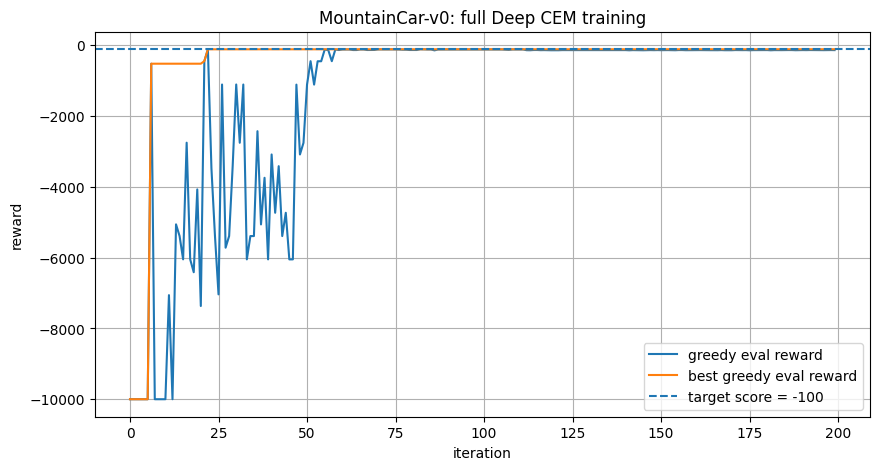

In [ ]:
agent_bonus = create_agent_bonus(random_state=42)

agent_bonus, log_bonus, best_agent_bonus = train_cem_mountain_car_full(
    agent_bonus,
    n_sessions=160,
    percentile=60,
    n_iterations=200,
    replay_size=5,
    t_max=10_000,
    epsilon_start=0.20,
    epsilon_min=0.02,
    epsilon_decay=0.97,
    train_epochs=3,
    target_score=-100,
    n_jobs=2
)

In [ ]:
final_mean, final_std = evaluate_policy_bonus(
    best_agent_bonus,
    n_games=100,
    t_max=10_000,
    n_jobs=2
)

print(f"Final greedy average reward: {final_mean:.2f} ± {final_std:.2f}")

Final greedy average reward: -115.31 ± 11.91


iteration: 79
epsilon: 0.005
mean true train reward: -125.52
CEM score threshold: 909.22
greedy eval reward: -115.70 ± 2.92
best greedy eval reward: -111.07
elapsed time: 476.5 sec


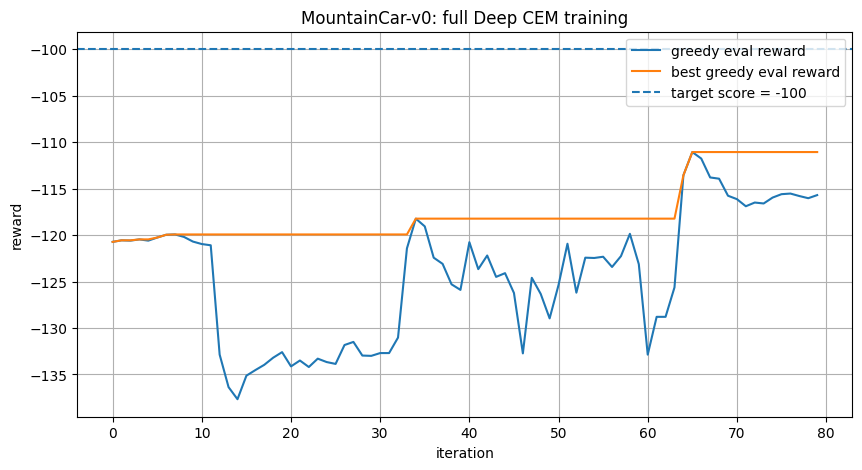

In [ ]:
agent_finetuned, log_finetuned, best_agent_finetuned = train_cem_mountain_car_full(
    best_agent_bonus,
    n_sessions=120,
    percentile=80,
    n_iterations=80,
    replay_size=3,
    t_max=700,
    epsilon_start=0.04,
    epsilon_min=0.005,
    epsilon_decay=0.96,
    train_epochs=5,
    target_score=-100,
    n_jobs=2
)

In [ ]:
def preprocess_states(states):
    states = np.asarray(states)

    if states.ndim == 1:
        states = states.reshape(1, -1)

    x = states[:, 0]
    v = states[:, 1]

    # MountainCar position примерно в диапазоне [-1.2, 0.6]
    x_scaled = 2 * (x - (-1.2)) / (0.6 - (-1.2)) - 1

    # MountainCar velocity примерно в диапазоне [-0.07, 0.07]
    v_scaled = v / 0.07

    return np.column_stack([
        x_scaled,
        v_scaled,
        x_scaled ** 2,
        v_scaled ** 2,
        x_scaled * v_scaled,
        np.sign(v_scaled),
        (v_scaled > 0).astype(float),
        (x_scaled > 0).astype(float),
    ])

In [ ]:
def create_agent_bonus(random_state=42):
    agent = MLPClassifier(
        hidden_layer_sizes=(256, 128),
        activation="tanh",
        solver="adam",
        learning_rate_init=5e-4,
        alpha=1e-5,
        max_iter=1,
        warm_start=True,
        random_state=random_state
    )

    s0, _ = env.reset(seed=random_state)

    agent.partial_fit(
        preprocess_states(np.repeat(s0[None, :], n_actions, axis=0)),
        np.arange(n_actions),
        classes=np.arange(n_actions)
    )

    return agent

In [ ]:
def generate_session_worker(
    agent,
    seed=None,
    t_max=10_000,
    epsilon=0.05,
    greedy=False
):
    local_env = gym.make("MountainCar-v0").env

    rng = np.random.default_rng(seed)

    states = []
    actions = []

    true_reward = 0.0
    s, _ = local_env.reset(seed=seed)

    max_position = s[0]
    reached_goal = False

    for t in range(t_max):
        probs = agent.predict_proba(preprocess_states([s]))[0]
        probs = probs / np.sum(probs)

        if greedy:
            a = int(np.argmax(probs))
        else:
            probs = (1 - epsilon) * probs + epsilon / local_env.action_space.n
            probs = probs / np.sum(probs)
            a = int(rng.choice(local_env.action_space.n, p=probs))

        new_s, r, terminated, truncated, _ = local_env.step(a)

        states.append(s)
        actions.append(a)

        true_reward += r
        max_position = max(max_position, new_s[0])

        s = new_s

        if terminated:
            reached_goal = True
            break

        if truncated:
            break

    local_env.close()

    if reached_goal:
        cem_score = 2000.0 + true_reward
    else:
        cem_score = true_reward + 500.0 * (max_position + 1.2)

    return states, actions, true_reward, cem_score

iteration: 119
epsilon: 0.005
mean true train reward: -104.42
CEM score threshold: 1897.00
greedy eval reward: -115.50 ± 21.84
best greedy eval reward: -102.37
elapsed time: 1747.6 sec


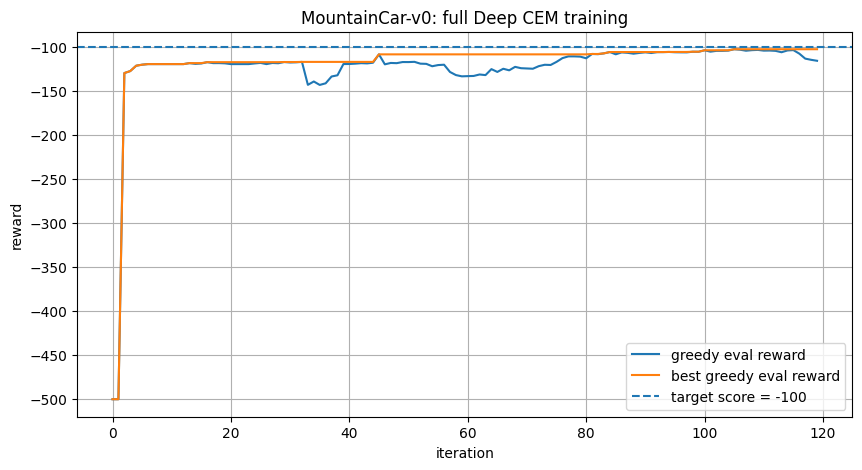

In [ ]:
agent_bonus_v2 = create_agent_bonus(random_state=123)

agent_bonus_v2, log_bonus_v2, best_agent_bonus_v2 = train_cem_mountain_car_full(
    agent_bonus_v2,
    n_sessions=160,
    percentile=75,
    n_iterations=120,
    replay_size=5,
    t_max=500,
    epsilon_start=0.12,
    epsilon_min=0.005,
    epsilon_decay=0.97,
    train_epochs=5,
    target_score=-100,
    n_jobs=2
)

In [ ]:
final_mean, final_std = evaluate_policy_bonus(
    best_agent_bonus_v2,
    n_games=100,
    t_max=10_000,
    n_jobs=2
)

print(f"Final greedy average reward: {final_mean:.2f} ± {final_std:.2f}")

Final greedy average reward: -101.93 ± 4.57


iteration: 79
epsilon: 0.001
mean true train reward: -120.27
CEM score threshold: 1913.00
greedy eval reward: -121.93 ± 27.49
best greedy eval reward: -101.37
elapsed time: 764.2 sec


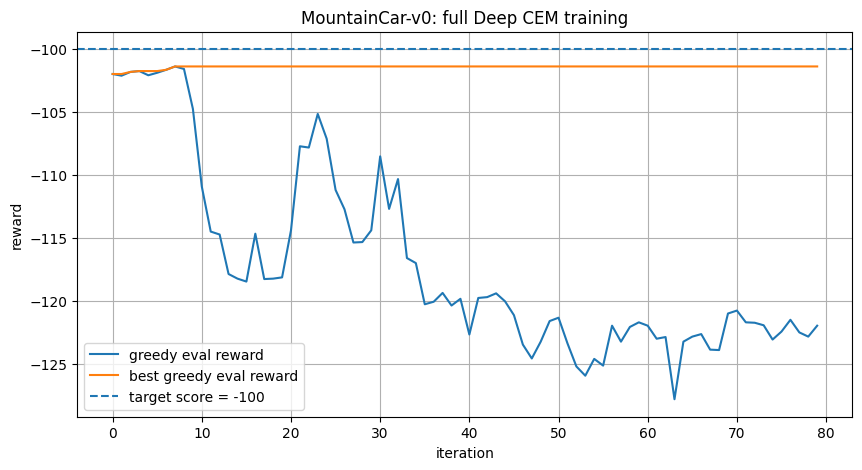

In [ ]:
import copy

agent_polish = copy.deepcopy(best_agent_bonus_v2)

agent_polish, log_polish, best_agent_polish = train_cem_mountain_car_full(
    agent_polish,
    n_sessions=220,
    percentile=90,
    n_iterations=80,
    replay_size=3,
    t_max=300,
    epsilon_start=0.025,
    epsilon_min=0.001,
    epsilon_decay=0.96,
    train_epochs=8,
    target_score=-100,
    n_jobs=2
)

In [ ]:
final_mean, final_std = evaluate_policy_bonus(
    best_agent_polish,
    n_games=100,
    t_max=10_000,
    n_jobs=2
)

print(f"Final greedy average reward: {final_mean:.2f} ± {final_std:.2f}")

Final greedy average reward: -100.93 ± 5.92


iteration: 49
epsilon: 0.002
mean true train reward: -124.69
CEM score threshold: 1911.00
greedy eval reward: -132.87 ± 31.95
best greedy eval reward: -100.77
elapsed time: 735.7 sec


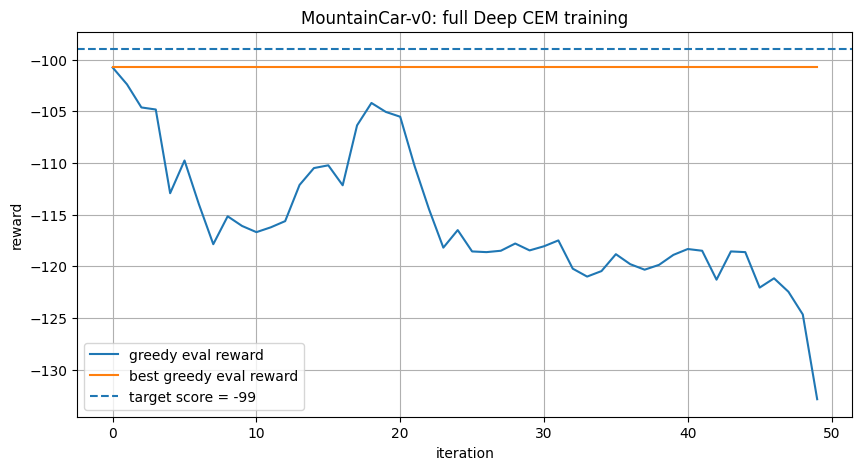

In [ ]:
import copy

agent_final = copy.deepcopy(best_agent_polish)

agent_final, log_final, best_agent_final = train_cem_mountain_car_full(
    agent_final,
    n_sessions=350,
    percentile=85,
    n_iterations=50,
    replay_size=2,
    t_max=220,
    epsilon_start=0.012,
    epsilon_min=0.001,
    epsilon_decay=0.96,
    train_epochs=8,
    target_score=-99,
    n_jobs=2
)

In [ ]:
final_mean, final_std = evaluate_policy_bonus(
    best_agent_final,
    n_games=100,
    t_max=10_000,
    n_jobs=2
)

print(f"Final greedy average reward: {final_mean:.2f} ± {final_std:.2f}")

Final greedy average reward: -100.45 ± 5.78


In [ ]:
def visualize_mountain_car(env, agent, t_max=10_000):
    base_env = env.unwrapped

    min_position = base_env.min_position
    max_position = base_env.max_position
    max_speed = base_env.max_speed

    # Compute policy for all possible x and v with discretization
    xs = np.linspace(min_position, max_position, 100)
    vs = np.linspace(-max_speed, max_speed, 100)

    X, V = np.meshgrid(xs, vs)
    grid_flat = np.column_stack([X.ravel(), V.ravel()])

    probs = agent.predict_proba(
        preprocess_states(grid_flat)
    ).reshape(len(vs), len(xs), 3)

    # Draw policy
    f, ax = plt.subplots(figsize=(7, 7))

    ax.imshow(
        probs,
        extent=(min_position, max_position, -max_speed, max_speed),
        origin="lower",
        aspect="auto",
    )

    ax.set_title("Learned policy: red=left, green=nothing, blue=right")
    ax.set_xlabel("position (x)")
    ax.set_ylabel("velocity (v)")

    # Sample one greedy trajectory and draw it
    states = []
    actions = []

    s, _ = env.reset()

    for t in range(t_max):
        probs_s = agent.predict_proba(preprocess_states([s]))[0]
        a = int(np.argmax(probs_s))

        states.append(s)
        actions.append(a)

        s, r, terminated, truncated, _ = env.step(a)

        if terminated or truncated:
            break

    states = np.array(states)

    ax.plot(states[:, 0], states[:, 1], color="white")

    # Draw every 3rd action from the trajectory
    for (x, v), a in zip(states[::3], actions[::3]):
        if a == 0:
            ax.arrow(x, v, -0.03, 0, color="white", head_length=0.01)
        elif a == 2:
            ax.arrow(x, v, 0.03, 0, color="white", head_length=0.01)

    plt.show()

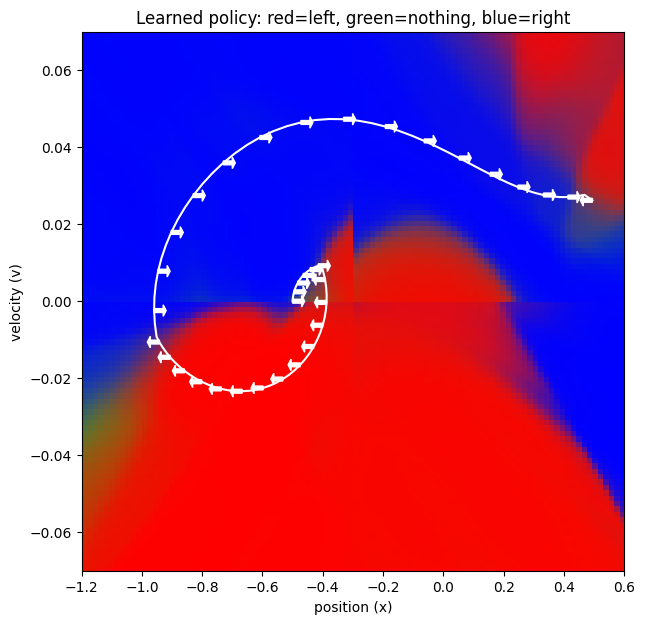

In [ ]:
env_vis = gym.make("MountainCar-v0", render_mode="rgb_array").unwrapped

visualize_mountain_car(env_vis, best_agent_final)

env_vis.close()

### Вывод

Я выбрала MountainCar-v0.

Сначала я обучила базового агента с помощью Deep Cross-Entropy Method. В этом варианте использовалась нейронная сеть, которая предсказывает вероятности трёх действий: ехать влево, не двигаться и ехать вправо. Базовая версия агента достигла среднего greedy reward около -146.

Затем я улучшила алгоритм обучения. Для этого я добавила предварительную обработку признаков состояния, так как исходное состояние MountainCar состоит только из двух чисел: позиции и скорости. Дополнительные признаки помогают нейронной сети лучше аппроксимировать полезную стратегию.

Также я использовала joblib для параллельной генерации сессий. Это ускоряет сбор траекторий, потому что несколько эпизодов могут запускаться одновременно.

Кроме того, я использовала повторное применение сессий из нескольких последних итераций. Это делает обучение стабильнее.

После этого я подбирала гиперпараметры: количество сессий, процентиль отбора elite-сессий, максимальную длину эпизода, параметры exploration через epsilon, число эпох обучения нейронной сети и архитектуру модели.

Результат постепенно улучшился: от около -146 в базовой версии до результата около -100 после улучшений и дообучения. Финальная greedy-оценка по 100 эпизодам составила примерно -100.45 ± 5.78.

Таким образом, агент уверенно превысил основной порог -150 для MountainCar-v0 и почти достиг дополнительной цели -100. Агент выучил разумную стратегию: он раскачивает машину влево-вправо, чтобы набрать скорость, а затем использует накопленный импульс, чтобы подняться на правую гору.

### Bonus tasks

* __2.3 bonus__ (2 pts) Try to find a network architecture and training params that solve __both__ environments above (_Points depend on implementation. If you attempted this task, please mention it in Anytask submission._)

* __2.4 bonus__ (4 pts) Solve continuous action space task with `MLPRegressor` or similar.
  * Since your agent only predicts the "expected" action, you will have to add noise to ensure exploration.
  * Choose one of [MountainCarContinuous-v0](https://gymnasium.farama.org/environments/classic_control/mountain_car_continuous/) (90+ pts to solve), [LunarLanderContinuous-v2](https://gymnasium.farama.org/environments/box2d/lunar_lander/) (`env = gym.make("LunarLander-v2", continuous=True)`)(200+ pts to solve)
  * 4 points for solving. Slightly less for getting some results below solution threshold. Note that discrete and continuous environments may have slightly different rules, aside from action spaces.